In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
df_train = pd.read_csv("/kaggle/input/datasets/vadimvilgurin/q-test-data/train.csv")

### Explore the data and check general statistics

In [3]:
df_train.head(5)

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,target
0,236,488,16,221,382,97,-4.472136,0.107472,0,132,...,13.340874,0.870542,1.962937,7.466666,11.547794,8.822916,9.046424,7.895535,11.010677,20.107472
1,386,206,357,232,1,198,7.810250,0.763713,1,143,...,12.484882,7.168680,2.885415,12.413973,10.260494,10.091351,9.270888,3.173994,13.921871,61.763713
2,429,49,481,111,111,146,8.602325,0.651162,1,430,...,14.030257,0.394970,8.160625,12.592059,8.937577,2.265191,11.255721,12.794841,12.080951,74.651162
3,414,350,481,370,208,158,8.306624,0.424645,1,340,...,2.789577,6.416708,10.549814,11.456437,6.468099,2.519049,0.258284,9.317696,5.383098,69.424645
4,318,359,20,218,317,301,8.124038,0.767304,1,212,...,1.886560,1.919999,2.268203,0.149421,4.105907,10.416291,6.816217,8.586960,4.512419,66.767304


In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 54 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       90000 non-null  int64  
 1   1       90000 non-null  int64  
 2   2       90000 non-null  int64  
 3   3       90000 non-null  int64  
 4   4       90000 non-null  int64  
 5   5       90000 non-null  int64  
 6   6       90000 non-null  float64
 7   7       90000 non-null  float64
 8   8       90000 non-null  int64  
 9   9       90000 non-null  int64  
 10  10      90000 non-null  int64  
 11  11      90000 non-null  int64  
 12  12      90000 non-null  int64  
 13  13      90000 non-null  float64
 14  14      90000 non-null  float64
 15  15      90000 non-null  float64
 16  16      90000 non-null  float64
 17  17      90000 non-null  float64
 18  18      90000 non-null  float64
 19  19      90000 non-null  float64
 20  20      90000 non-null  float64
 21  21      90000 non-null  float64
 22

In [9]:
pd.set_option("display.max_columns", None)
df_train.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,target
count,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,249.423944,250.236267,248.637289,249.736600,249.436178,249.656167,-0.011402,0.498548,0.499189,249.842033,249.818967,249.346778,249.899900,7.483940,7.498037,7.496259,7.501635,7.486463,7.523043,7.475585,7.494835,7.503939,7.507724,7.508681,7.472421,7.519205,7.515753,7.509402,7.496781,7.504014,7.494212,7.490808,7.486936,7.514508,7.491614,7.520193,7.507801,7.493713,7.513840,7.507033,7.479579,7.519826,7.502483,7.512965,7.475155,7.523962,7.508397,7.473322,7.490658,7.474578,7.509206,7.487159,7.513316,50.033981
std,144.336393,144.022200,144.107577,144.284945,143.941581,144.329168,7.038171,0.288682,0.500002,144.612718,144.363827,144.476128,144.310495,4.330908,4.318388,4.338732,4.345618,4.318031,4.323500,4.327327,4.325447,4.330159,4.332599,4.328966,4.345228,4.339104,4.333907,4.331007,4.334982,4.318553,4.327286,4.322672,4.329524,4.329973,4.333144,4.335244,4.329515,4.327480,4.333543,4.327670,4.326175,4.315565,4.333881,4.329929,4.330410,4.321537,4.331761,4.335692,4.332122,4.323035,4.326364,4.324876,4.333080,28.897243
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.949874,0.000014,0.000000,0.000000,0.000000,0.000000,0.000000,0.000095,0.000252,0.000190,0.000192,0.000067,0.000229,0.000125,0.000382,0.000398,0.000140,0.000382,0.000129,0.000192,0.000017,0.000080,0.000161,0.000437,0.000041,0.000070,0.000074,0.000111,0.000067,0.000078,0.000018,0.000094,0.000020,0.000106,0.000105,0.000273,0.000315,0.000060,0.000019,0.000040,0.000154,0.000083,0.000367,0.000014,0.000160,0.000147,0.000125,0.002634
25%,125.000000,126.000000,124.000000,125.000000,125.000000,124.000000,-7.071068,0.248932,0.000000,124.000000,126.000000,124.000000,125.000000,3.723392,3.763626,3.718755,3.719537,3.758746,3.778857,3.733780,3.748951,3.760261,3.742810,3.768145,3.685140,3.760790,3.746467,3.772795,3.741697,3.774239,3.743116,3.763061,3.750034,3.778028,3.743842,3.752848,3.776405,3.755325,3.754465,3.771945,3.731527,3.784809,3.763004,3.768044,3.707544,3.797002,3.760627,3.715721,3.739358,3.715298,3.773381,3.743536,3.776322,25.091903
50%,250.000000,251.000000,248.000000,250.000000,250.000000,250.000000,0.000000,0.497136,0.000000,250.000000,250.000000,249.000000,251.000000,7.483265,7.505267,7.502682,7.515240,7.467721,7.539462,7.460267,7.481500,7.521563,7.520793,7.520739,7.484349,7.526894,7.528984,7.494876,7.491009,7.500083,7.514475,7.483334,7.458614,7.513794,7.475324,7.550623,7.484699,7.472789,7.518614,7.504101,7.452493,7.532363,7.511806,7.507058,7.474127,7.533987,7.505259,7.459774,7.494167,7.477270,7.512575,7.476564,7.506812,50.030705
75%,374.000000,375.000000,374.000000,375.000000,373.000000,374.000000,7.000000,0.747513,1.000000,376.000000,375.000000,375.000000,375.000000,11.242883,11.228331,11.258049,11.284618,11.238904,11.254751,11.211187,11.238128,11.248749,11.244657,11.240915,11.239795,11.276738,11.272683,11.271486,11.257988,11.233189,11.223296,11.229486,11.245719,11.272623,11.241922,11.261178,11.255442,11.251097,11.270277,11.241504,11.222543,11.241135,11.255483,11.272459,11.216585,11.276349,11.261971,11.215637,11.239232,11.210070,11.268156,11.234414,11.277835,75.059454
max,499.000000,499.000000,499.000000,499.00000

### Missing values check

In [10]:
df_train.isnull().mean().sort_values().iloc[0].item()

0.0

### Target distribution

<Axes: >

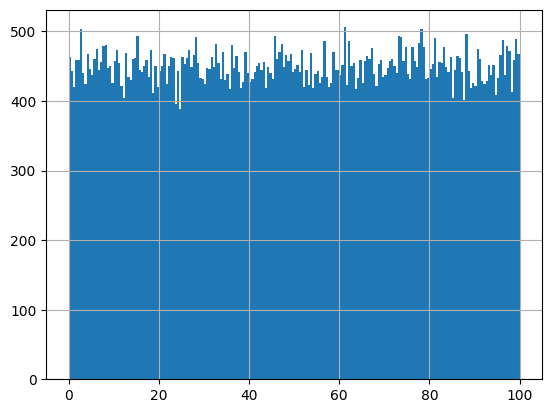

In [11]:
df_train["target"].hist(bins=200)

#### Analysis
    Initial insights:
    1.
        1) columns 0-5, 9-12: span 0 - 499 integer values, looks like a uniform distribution
        2) columns 13-52: all look similar, uniform distribution, continuous values
        3) columns 6-8: weirdos
        
        Column 6 - the only non-uniform continuous column, need to check the distribution
        Column 7 - uniform in [0, 1]
        Column 8 - binary value, possibly represents a gate operator in the dataset
        
        There are some interesting columns (6-8) and lots of quite similar variables in the dataset, which need more investigation.
    2. No missing values
    3. Target distribution is uniform

    What to do next:
        1. Too many features:
            1) Check the linear relationship with the target with the help of the correlation matrix
            2) Check if some features are more important than others and investigate their relationship with the target. The target might need lots of features for approximation or only use some. In the case of the latter, removing uninformative features might lead to a better model's performance as we get rid of noise.
            3) Investigate weirdos
            


### Correlation

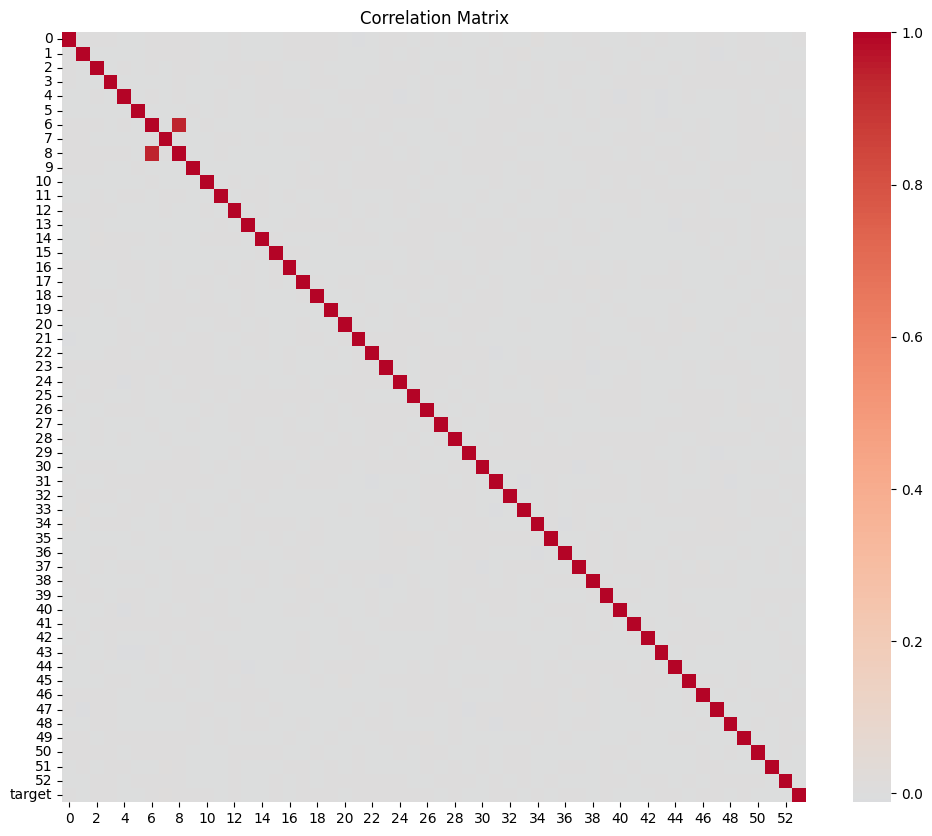

In [12]:
corr = df_train.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

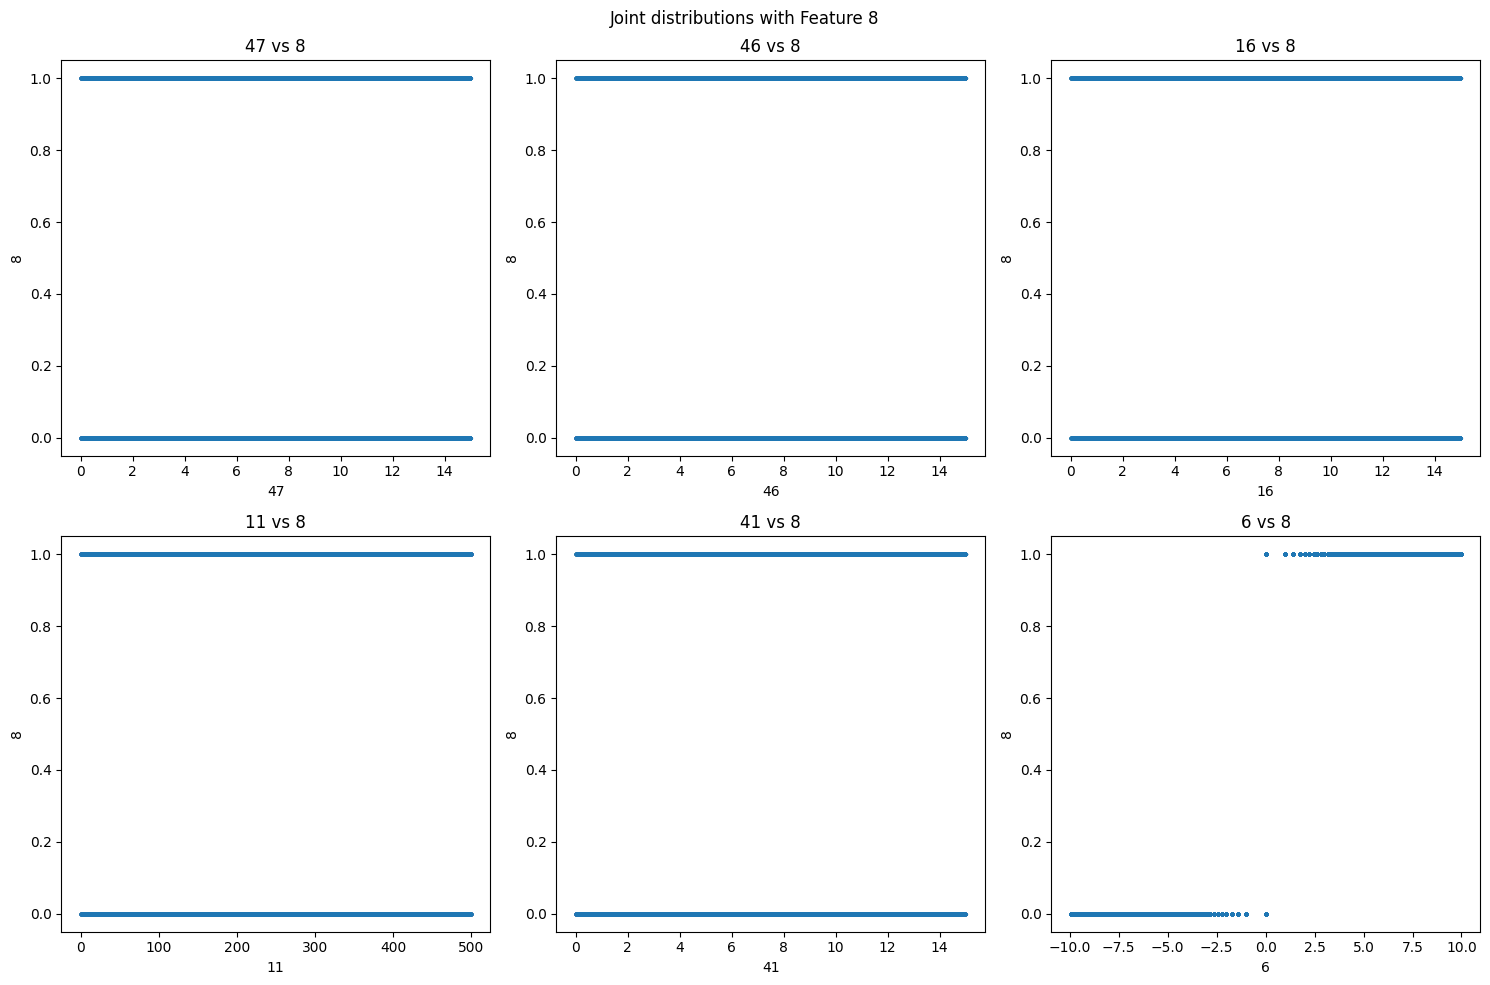

In [7]:
reference_feature = "8"
signal_feature = "6"

all_features = [
    c for c in df_train.columns
    if c not in ["target", signal_feature, reference_feature]
]

random_features = np.random.choice(all_features, size=5, replace=False)
features_to_plot = list(random_features) + [signal_feature]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, feat in zip(axes.flatten(), features_to_plot):
    ax.scatter(df_train[feat], df_train[reference_feature], s=2)
    ax.set_xlabel(feat)
    ax.set_ylabel(reference_feature)
    ax.set_title(f"{feat} vs {reference_feature}")

plt.suptitle("Joint distributions with Feature 8")
plt.tight_layout()
plt.show()

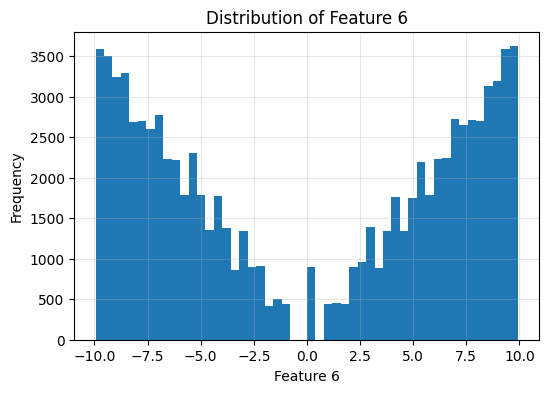

In [8]:
plt.figure(figsize=(6, 4))
df_train["6"].hist(bins=50)

plt.title("Distribution of Feature 6")
plt.xlabel("Feature 6")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

plt.show()

#### Analysis
There is no linear correlation between features and the target. That only means that the relationship is non-linear, and we are not going to be using a linear model.

The relationship between Feature 6 and Feature 8 is interesting, and it is clear why they are closely related. Feature 6 is the only non-uniform non-categorical feature in the dataset. Feature 8 seems to hint at how Feature 6 is generated, which explains the correlation. Feature 6 is symmetric around 0, the left tail is negative and corresponds to Feature 8 = 0, and the positive right tail corresponds to Feature 8 = 1. However, it is not clear if feature 8 is used to define any other rules in the data. No meaningful structure in other features' relationships with Feature 8

The distribution of Feature 6 is much different from all the other features and might play a crucial role in predicting the target. That feature is worth invistigating more.

### Train Random Forest model

In [9]:
X = df_train.drop(columns=["target"])
y = df_train["target"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.9,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth = 16,
)

model.fit(X_train, y_train)
preds = model.predict(X_valid)
rmse = root_mean_squared_error(y_valid, preds)

print("Validation RMSE:", rmse)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df)

Validation RMSE: 0.05250304510375561
   feature    importance
6        6  9.999037e-01
7        7  9.259327e-05
21      21  8.769023e-08
24      24  8.695200e-08
0        0  8.415382e-08
22      22  8.080306e-08
11      11  8.054716e-08
39      39  8.049556e-08
23      23  8.040165e-08
27      27  8.019249e-08
47      47  8.004442e-08
10      10  7.894084e-08
14      14  7.817745e-08
51      51  7.798968e-08
2        2  7.758115e-08
41      41  7.732842e-08
1        1  7.720964e-08
46      46  7.691374e-08
38      38  7.611869e-08
34      34  7.561078e-08
19      19  7.558465e-08
52      52  7.556557e-08
15      15  7.519605e-08
40      40  7.504584e-08
50      50  7.480538e-08
13      13  7.469277e-08
42      42  7.444590e-08
25      25  7.442323e-08
37      37  7.430302e-08
29      29  7.380391e-08
36      36  7.375924e-08
43      43  7.332695e-08
30      30  7.320704e-08
45      45  7.193560e-08
3        3  7.167867e-08
49      49  7.165807e-08
33      33  7.165399e-08
28      28  7

In [3]:
X = df_train[["6", "7"]]
y = df_train["target"]


X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.9,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth = 16,
)
model.fit(X_train, y_train)
preds = model.predict(X_valid)
rmse = root_mean_squared_error(y_valid, preds)
print("RMSE = ", rmse)

RMSE =  0.02802768181718388


### Analysis
We have identified the features with a clear structure and dependency - 6 and 8 (both belong to weirdos). Before analysing the last one, "Feature 7", we first check if there are any other features worth investigating. To do so, we fit a simple non-linear tree-based model. There are a couple of options to choose the model, since SVM with RBF kernel or a simple MLP might find the non-linear transformation accurately as well. However, for the EDA purposes, we stick to the Random Forest model that does not require any data processing (scaling, outlier filtering) and is very explainable. We want to take a look at the feature importance rates to limit the number of features we are interested in.


There are a couple of crucial findings of RF fit:<br>


    1. RMSE is extremely low (the naive baseline would be the model that predicts the mean all the time, and the error would be equal  to 29, which is the std). That hints at the fact that the model has found a shortcut/specific rule in the data to model the target distribution.<br>
    
    2. Importance scores reveal that the model relies heavily on Feature 6 and Feature 7 compared to all the others. Firstly, Feature 8 is probably only used to generate Feature 6 (if that is even the case) and does not affect the target. All the other features are probably noise. To make sure, we fit the model again on the curated data, only keeping Features 6 and 7 in the dataset. That leads to even better performance that suports the argument that all the other features are probably noise.

Next:
    We can safely move to investigating the Features 6 and 7 that take the most crucial part in predicting the target. Looking for:

        - outliers
        - skewness
        - anomalies

### Feature distribution

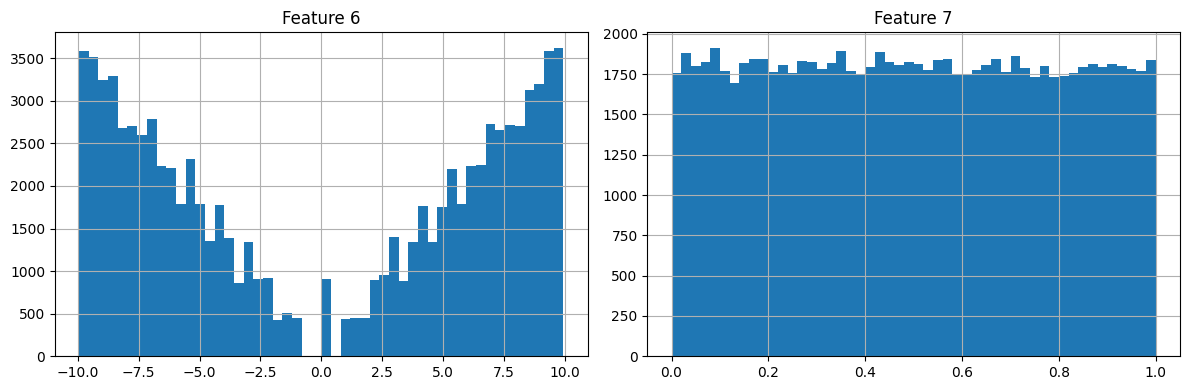

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_train["6"].hist(ax=axes[0], bins=50)
axes[0].set_title("Feature 6")

df_train["7"].hist(ax=axes[1], bins=50)
axes[1].set_title("Feature 7")

plt.tight_layout()
plt.show()

### Box plots

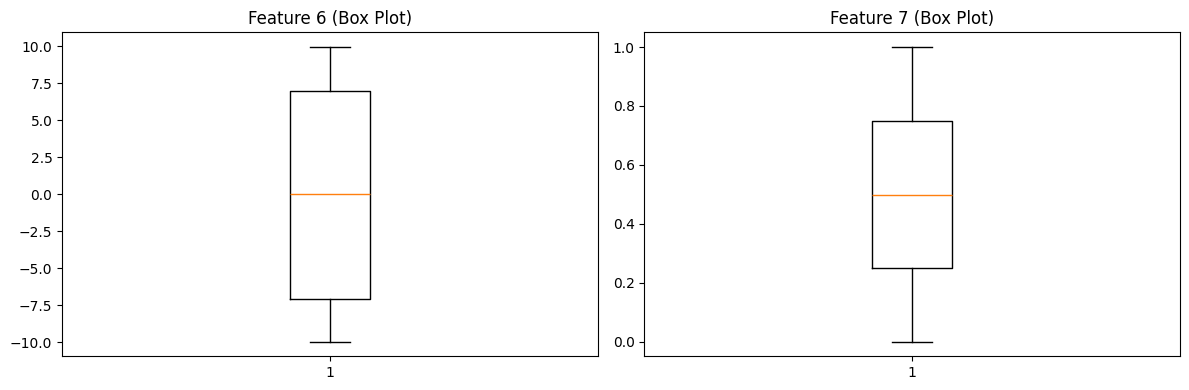

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df_train["6"])
axes[0].set_title("Feature 6 (Box Plot)")

axes[1].boxplot(df_train["7"])
axes[1].set_title("Feature 7 (Box Plot)")

plt.tight_layout()
plt.show()

### Joint feature-target distribution

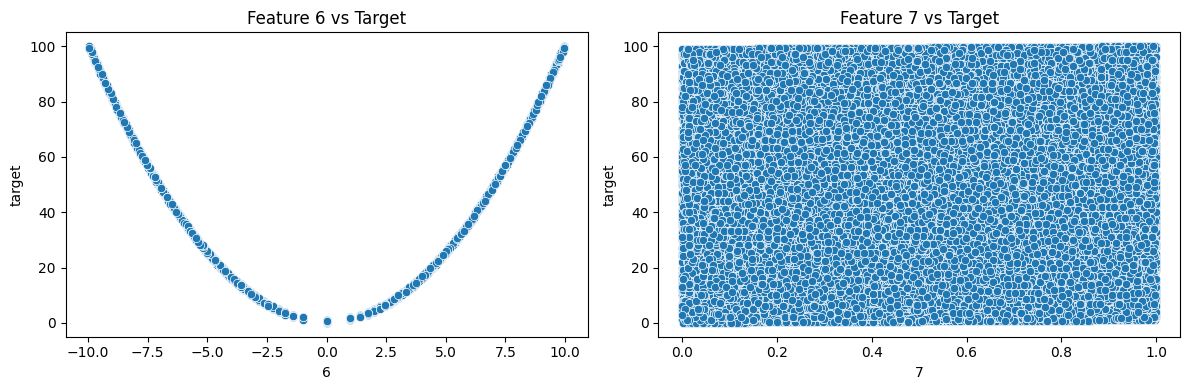

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(x=df_train["6"], y=df_train["target"], ax=axes[0])
axes[0].set_title("Feature 6 vs Target")

sns.scatterplot(x=df_train["7"], y=df_train["target"], ax=axes[1])
axes[1].set_title("Feature 7 vs Target")

plt.tight_layout()
plt.show()

Both distributions look clean, no outliers detected. Plotting the features against Target reveals a very interesting structure in Feature 6 vs Target. We can apply a power transformation to Feature 6 to make the relationship more linear. 

Text(0.5, 1.0, 'Feature 6 vs Target')

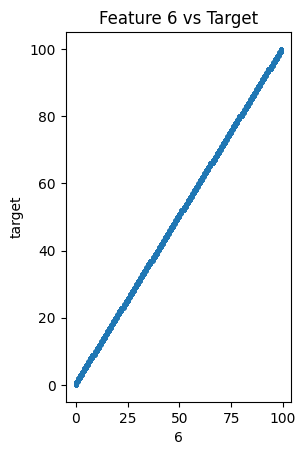

In [5]:
plt.subplot(1, 2, 1)
plt.scatter(df_train["6"]**2, df_train["target"], s=2)
plt.xlabel("6")
plt.ylabel("target")
plt.title("Feature 6 vs Target")

In [25]:
residuals = df_train["6"]**2 - df_train["target"]
print(f"Mean of residuals = {residuals.mean()}")
print(f"Std of residuals = {residuals.std()}")
print(f"Mean of feature 7 = {df_train["7"].mean()}")
print(f"Std of feature 7 = {df_train["7"].std()}")
print(f"The difference between Feature 7 and Residuals = {(residuals + df_train['7']).mean()}")

Mean of residuals = -0.49854764874099233
Std of residuals = 0.28868240351659363
Mean of feature 7 = 0.49854764874099256
Std of feature 7 = 0.28868240351659347
The difference between Feature 7 and Residuals = 2.7598313899395807e-16


In [40]:
print (f"Final RMSE = {root_mean_squared_error(df_train["6"]**2 + df_train['7'], df_train["target"])}")

Final RMSE = 9.687150056212742e-15


We transform Feature 6, the relationship between the transformed feature and the target becomes linear, and we can look at the residuals. As for now the final formula might be equal to something like : A*(F6)^2 + B*g(F7), where A and B - constants, g - some function.
After invstigating the residuals, we clearly see they are actually equal to F7 (same mean, std). We finalize the transformation and find out that the error between F6^2+F7 and Target is practically 0. Thus, we do not need the model to approximate the target, and we will use this formula to predict the target in the test set.